In [ ]:
# Text Classification

In [ ]:
import csv
input_file= "symptoms_all.csv"
output_file="symptoms_all_variables.csv"
with open(input_file, 'r') as csvfile:
    with open(output_file, 'w', newline='') as f:
        spamreader = csv.reader(csvfile, delimiter=',')
        for row in spamreader:
            need = [row[0], row[8],row[22],row[25],row[37],row[45],row[47],row[64],row[101], row[116], row[253], row[280]]
            len_need = len(need)
            for i in range(len_need):
                if need[i] == '':
                   need[i] = "0"
                elif need[i] == 'y':
                   need[i] = "1"
                else:
                   continue

            if need[0] == 'y':
               need[0] = "1"
            #print(need)



            thewriter = csv.writer(f)
            thewriter.writerow(need)
            #f.write("%s %s %s %s %s %s %s %s %s %s %s\n" %(need[8],need[22],need[25],need[37],need[45],need[47],need[64],need[101], need[116], need[248], need[279]))


FileNotFoundError: ignored

In [ ]:
import numpy as np
import pandas as pd
from sklearn import metrics
from patsy import dmatrices
import statsmodels.api as sm
from keras import models
from keras import layers
from keras.layers import Dense
from keras.models import Model
import matplotlib.pyplot as plt
from keras.layers import Dropout
from keras.layers import Flatten
from tensorflow.keras.optimizers import SGD
from keras.layers import Flatten
from nltk.corpus import stopwords
from sklearn import datasets, svm
from keras.models import Sequential
from keras.layers import Embedding
from pandas import Series, DataFrame
from keras.layers import MaxPooling1D
from gensim.models import KeyedVectors
from tensorflow.keras.utils import to_categorical
from sklearn.linear_model import SGDClassifier
from keras.preprocessing.text import Tokenizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from statsmodels.nonparametric import smoothers_lowess
from keras.preprocessing.sequence import pad_sequences
from statsmodels.nonparametric.kde import KDEUnivariate
from keras.layers import Conv1D, GlobalMaxPooling1D, Conv2D, MaxPooling2D
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.naive_bayes import MultinomialNB

import re
import nltk
import gensim
import logging
import bs4 as bs
import urllib.request
import xgboost as xgb
import multiprocessing
import texthero as hero
from gensim import utils
from sklearn import utils
from hyperas import optim
from tqdm import tqdm
tqdm.pandas(desc="progress-bar")
from gensim.models import Doc2Vec
from nltk.corpus import stopwords
from xgboost import XGBClassifier
from nltk.stem import SnowballStemmer
from sklearn.metrics import accuracy_score
from hyperopt import Trials, STATUS_OK, tpe
from gensim.models.doc2vec import TaggedDocument
from hyperas.distributions import choice, uniform
from gensim.models.doc2vec import LabeledSentence
from sklearn.linear_model import LogisticRegression
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_classification

from sklearn.model_selection import cross_val_score
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import sent_tokenize, word_tokenize

dataset = pd.read_csv(output_file)
dataset

,Id,female,tuber,diabetes,men_con,cough,ch_cough,diarr,exc_urine,exc_drink,disease_description,finaldiagnosis
0,100018,0,1,0,0,1,1,0,0,1,The deceased developed blisters under the righ...,0.0
1,100078,1,0,0,0,1,1,1,0,0,At first the deceased was complaining about br...,0.0
2,100096,1,1,0,0,1,1,0,0,1,She was complaining about hot feet with swelli...,0.0
3,100101,1,0,0,0,0,0,0,0,0,At first deceased complained headache and stom...,0.0
4,100108,0,0,0,1,0,0,0,0,1,Beginning of illness deceased dreamed eating f...,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8693,631156,1,0,0,0,0,0,0,0,0,She started by complaining with headache and a...,0.0
8694,632743,0,0,0,0,0,0,0,0,0,0,0.0
8695,633179,1,0,0,0,0,0,0,0,0,The deceased started by having painful abdomen...,0.0
8696,633559,0,0,0,0,0,0,0,0,0,0,0.0


In [ ]:
dataset = pd.read_csv("NewVA.csv")
dataset

,female,tuber,diabetes,men_con,cough,ch_cough,diarr,exc_urine,exc_drink,disease_description,finaldiagnosis
0,0,1,0,0,1,1,0,0,1,The deceased developed blisters under the righ...,0
1,1,0,0,0,1,1,1,0,0,At first the deceased was complaining about br...,0
2,1,1,0,0,1,1,0,0,1,She was complaining about hot feet with swelli...,0
3,1,0,0,0,0,0,0,0,0,At first deceased complained headache and stom...,0
4,0,0,0,1,0,0,0,0,1,Beginning of illness deceased dreamed eating f...,0
...,...,...,...,...,...,...,...,...,...,...,...
7828,1,1,0,1,1,1,1,0,0,"She started by coughing, fever and have diarrh...",0
7829,1,0,0,0,1,0,0,0,0,The deceased started by coughing where she was...,0
7830,1,0,0,0,0,0,0,0,0,She started by complaining with headache and a...,0
7831,1,0,0,0,0,0,0,0,0,The deceased started by having painful abdomen...,0


In [ ]:
y3 = dataset["finaldiagnosis"]
y3

0       0
1       0
2       0
3       0
4       0
       ..
7828    0
7829    0
7830    0
7831    0
7832    0
Name: finaldiagnosis, Length: 7833, dtype: int64

In [ ]:
import numpy as np
numpy3 = np.load('VAfinal.npy')
numpy3.shape

(7833, 1024)

In [ ]:
import numpy as np
numpy = np.load('VAUnbert.npy')
numpy.shape

(7833, 768)

In [ ]:
#Coverting a numpy array into a data frame
df = pd.DataFrame(numpy3)
df

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0.004564,-0.120841,-0.052309,0.035599,0.255980,0.099682,-0.015817,0.070443,0.026577,-0.034131,...,-0.176981,0.077741,-0.254013,0.174829,0.087478,-0.167544,0.195741,-0.022200,0.242364,-0.011167
1,-0.050153,-0.077620,-0.026939,0.041262,0.039626,-0.005777,0.026339,0.024487,0.031090,-0.047381,...,-0.093294,0.060347,-0.138804,0.099360,0.142559,0.020748,0.109140,-0.123124,0.152700,0.032298
2,-0.052979,-0.136088,-0.001635,-0.009231,0.163561,0.076659,-0.017045,0.140401,0.049699,-0.025526,...,-0.172036,0.051360,-0.323644,0.192220,0.250814,-0.045714,0.148654,-0.271900,0.245191,0.090927
3,-0.031350,-0.049682,-0.075050,0.019156,0.083267,0.025576,-0.037541,-0.001368,-0.011396,-0.042416,...,-0.131446,0.055148,-0.388169,0.114679,0.254893,-0.027675,0.286690,-0.135815,0.289187,0.118043
4,0.025624,-0.034638,-0.012002,0.053103,0.130267,0.024316,0.025760,0.040957,0.064720,-0.087623,...,-0.055247,0.041282,-0.122767,0.114340,0.124288,-0.093404,0.117231,-0.032511,0.096539,0.007415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7828,-0.372723,-0.159081,-0.075431,-0.017206,0.267100,0.048819,0.030994,0.105078,0.040774,0.122278,...,-0.053566,0.121291,-0.470063,0.157353,0.226535,-0.176938,0.238634,-0.390751,0.493911,-0.026440
7829,-0.026141,-0.024567,-0.019867,-0.003837,0.065251,-0.024389,0.007481,-0.039854,0.081067,-0.060303,...,-0.067015,0.036184,-0.239099,0.050472,0.047480,-0.117558,0.113250,-0.111803,0.022561,0.036697
7830,-0.205241,-0.065048,-0.090375,0.022364,0.216916,0.004334,0.021507,-0.024051,0.151989,0.180903,...,-0.079072,0.133106,-0.461141,0.126967,0.220512,-0.122172,0.108370,-0.408294,0.406685,-0.037725
7831,-0.094796,-0.037215,-0.108371,0.073509,0.055189,-0.075038,-0.014593,-0.017725,0.130903,-0.001882,...,-0.048258,0.076977,-0.288997,0.164282,0.033209,-0.087609,0.078943,-0.216378,0.108781,0.006498


In [ ]:
#Coverting a numpy array into a data frame
df2 = pd.DataFrame(numpy)
df2

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,0.075627,0.132981,0.128455,0.905081,0.991933,0.882216,0.631269,0.180067,-0.092080,0.405289,...,0.086050,0.911581,-0.854586,0.648514,0.882056,0.490923,-0.781812,-0.398814,-0.883501,-0.442142
1,0.874110,-0.512967,0.025296,-0.966775,-0.214251,-0.715966,-0.707653,0.833488,0.349612,-0.205862,...,-0.409567,-0.831409,0.462622,0.314237,0.653831,0.257510,-0.805141,-0.339686,0.416634,0.151783
2,0.698588,0.467158,0.410709,-0.810982,0.029012,0.067626,-0.181474,0.864893,-0.171834,-0.932124,...,-0.894625,-0.784692,0.330545,-0.783493,0.477859,0.494536,-0.817453,0.619266,0.611336,-0.087373
3,0.549374,-0.087779,0.800487,0.114196,-0.419980,-0.460071,-0.542703,0.911329,-0.320412,-0.951281,...,-0.857571,-0.649075,-0.422010,0.320293,0.490858,0.268078,-0.662021,0.235697,-0.013814,-0.249511
4,0.857971,-0.819153,0.020909,-0.989702,-0.163710,-0.552804,-0.746518,0.656542,0.399067,0.645334,...,-0.055571,-0.858617,0.422339,-0.150346,0.591782,0.317968,-0.539443,-0.302800,0.774663,0.084319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7828,0.552922,-0.030437,0.705118,-0.725346,-0.257711,-0.693921,-0.565398,0.915197,0.452489,-0.804668,...,-0.911566,-0.753274,-0.084145,-0.484399,0.268475,0.410147,-0.594288,0.591290,-0.242765,-0.188511
7829,0.895895,-0.653593,-0.020826,-0.981458,-0.152704,-0.549552,-0.688950,0.846517,0.389257,-0.101193,...,0.097021,-0.765114,0.484713,0.046832,0.555670,0.067885,-0.759208,-0.306088,0.297535,0.296566
7830,0.843698,-0.749100,0.280108,-0.993174,-0.451919,-0.503397,-0.541013,0.661341,0.633278,0.213232,...,-0.274688,-0.641834,0.553275,0.042796,0.577361,0.525815,-0.402874,-0.080782,0.228377,-0.137405
7831,0.782707,-0.670501,-0.326957,-0.994221,-0.277875,-0.670175,-0.670645,0.747636,0.548301,0.354116,...,0.185384,-0.876752,0.563466,0.137789,0.459504,0.385256,-0.566692,-0.363740,0.350959,0.175493


In [ ]:
x5 = pd.concat([df,df2], axis = 1, ignore_index=True)
x5

,0,1,2,3,4,5,6,7,8,9,...,1782,1783,1784,1785,1786,1787,1788,1789,1790,1791
0,0.004564,-0.120841,-0.052309,0.035599,0.255980,0.099682,-0.015817,0.070443,0.026577,-0.034131,...,0.086050,0.911581,-0.854586,0.648514,0.882056,0.490923,-0.781812,-0.398814,-0.883501,-0.442142
1,-0.050153,-0.077620,-0.026939,0.041262,0.039626,-0.005777,0.026339,0.024487,0.031090,-0.047381,...,-0.409567,-0.831409,0.462622,0.314237,0.653831,0.257510,-0.805141,-0.339686,0.416634,0.151783
2,-0.052979,-0.136088,-0.001635,-0.009231,0.163561,0.076659,-0.017045,0.140401,0.049699,-0.025526,...,-0.894625,-0.784692,0.330545,-0.783493,0.477859,0.494536,-0.817453,0.619266,0.611336,-0.087373
3,-0.031350,-0.049682,-0.075050,0.019156,0.083267,0.025576,-0.037541,-0.001368,-0.011396,-0.042416,...,-0.857571,-0.649075,-0.422010,0.320293,0.490858,0.268078,-0.662021,0.235697,-0.013814,-0.249511
4,0.025624,-0.034638,-0.012002,0.053103,0.130267,0.024316,0.025760,0.040957,0.064720,-0.087623,...,-0.055571,-0.858617,0.422339,-0.150346,0.591782,0.317968,-0.539443,-0.302800,0.774663,0.084319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7828,-0.372723,-0.159081,-0.075431,-0.017206,0.267100,0.048819,0.030994,0.105078,0.040774,0.122278,...,-0.911566,-0.753274,-0.084145,-0.484399,0.268475,0.410147,-0.594288,0.591290,-0.242765,-0.188511
7829,-0.026141,-0.024567,-0.019867,-0.003837,0.065251,-0.024389,0.007481,-0.039854,0.081067,-0.060303,...,0.097021,-0.765114,0.484713,0.046832,0.555670,0.067885,-0.759208,-0.306088,0.297535,0.296566
7830,-0.205241,-0.065048,-0.090375,0.022364,0.216916,0.004334,0.021507,-0.024051,0.151989,0.180903,...,-0.274688,-0.641834,0.553275,0.042796,0.577361,0.525815,-0.402874,-0.080782,0.228377,-0.137405
7831,-0.094796,-0.037215,-0.108371,0.073509,0.055189,-0.075038,-0.014593,-0.017725,0.130903,-0.001882,...,0.185384,-0.876752,0.563466,0.137789,0.459504,0.385256,-0.566692,-0.363740,0.350959,0.175493


In [ ]:
x6 = pd.concat([x5,y3], axis = 1)

In [ ]:
data = x6.replace("#NULL!",np.NAN)

In [ ]:
data1 = data.replace(np.NAN,-1)
data1

,0,1,2,3,4,5,6,7,8,9,...,1783,1784,1785,1786,1787,1788,1789,1790,1791,finaldiagnosis
0,0.004564,-0.120841,-0.052309,0.035599,0.255980,0.099682,-0.015817,0.070443,0.026577,-0.034131,...,0.911581,-0.854586,0.648514,0.882056,0.490923,-0.781812,-0.398814,-0.883501,-0.442142,0
1,-0.050153,-0.077620,-0.026939,0.041262,0.039626,-0.005777,0.026339,0.024487,0.031090,-0.047381,...,-0.831409,0.462622,0.314237,0.653831,0.257510,-0.805141,-0.339686,0.416634,0.151783,0
2,-0.052979,-0.136088,-0.001635,-0.009231,0.163561,0.076659,-0.017045,0.140401,0.049699,-0.025526,...,-0.784692,0.330545,-0.783493,0.477859,0.494536,-0.817453,0.619266,0.611336,-0.087373,0
3,-0.031350,-0.049682,-0.075050,0.019156,0.083267,0.025576,-0.037541,-0.001368,-0.011396,-0.042416,...,-0.649075,-0.422010,0.320293,0.490858,0.268078,-0.662021,0.235697,-0.013814,-0.249511,0
4,0.025624,-0.034638,-0.012002,0.053103,0.130267,0.024316,0.025760,0.040957,0.064720,-0.087623,...,-0.858617,0.422339,-0.150346,0.591782,0.317968,-0.539443,-0.302800,0.774663,0.084319,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7828,-0.372723,-0.159081,-0.075431,-0.017206,0.267100,0.048819,0.030994,0.105078,0.040774,0.122278,...,-0.753274,-0.084145,-0.484399,0.268475,0.410147,-0.594288,0.591290,-0.242765,-0.188511,0
7829,-0.026141,-0.024567,-0.019867,-0.003837,0.065251,-0.024389,0.007481,-0.039854,0.081067,-0.060303,...,-0.765114,0.484713,0.046832,0.555670,0.067885,-0.759208,-0.306088,0.297535,0.296566,0
7830,-0.205241,-0.065048,-0.090375,0.022364,0.216916,0.004334,0.021507,-0.024051,0.151989,0.180903,...,-0.641834,0.553275,0.042796,0.577361,0.525815,-0.402874,-0.080782,0.228377,-0.137405,0
7831,-0.094796,-0.037215,-0.108371,0.073509,0.055189,-0.075038,-0.014593,-0.017725,0.130903,-0.001882,...,-0.876752,0.563466,0.137789,0.459504,0.385256,-0.566692,-0.363740,0.350959,0.175493,0


In [ ]:
#Divide train_data into input and target values
x4 = data1.drop("finaldiagnosis", axis = 1)
y4 = data1["finaldiagnosis"]
x4, y4

(          0         1         2         3         4         5         6     \
 0     0.004564 -0.120841 -0.052309  0.035599  0.255980  0.099682 -0.015817   
 1    -0.050153 -0.077620 -0.026939  0.041262  0.039626 -0.005777  0.026339   
 2    -0.052979 -0.136088 -0.001635 -0.009231  0.163561  0.076659 -0.017045   
 3    -0.031350 -0.049682 -0.075050  0.019156  0.083267  0.025576 -0.037541   
 4     0.025624 -0.034638 -0.012002  0.053103  0.130267  0.024316  0.025760   
 ...        ...       ...       ...       ...       ...       ...       ...   
 7828 -0.372723 -0.159081 -0.075431 -0.017206  0.267100  0.048819  0.030994   
 7829 -0.026141 -0.024567 -0.019867 -0.003837  0.065251 -0.024389  0.007481   
 7830 -0.205241 -0.065048 -0.090375  0.022364  0.216916  0.004334  0.021507   
 7831 -0.094796 -0.037215 -0.108371  0.073509  0.055189 -0.075038 -0.014593   
 7832 -0.042529 -0.044915  0.043021 -0.014002 -0.019440 -0.002945  0.037485   
 
           7         8         9     ...      1782

In [ ]:
# Neural Network  #SMOTETomek Sampling
np.random.seed(0)
number_of_features= 1792

#Create function returning a compiled network
def create_network():

    # Start neural network
    network = models.Sequential()

    # Add fully connected layer with a ReLU activation function
    network.add(layers.Dense(units=16, activation='relu', input_shape=(number_of_features,)))

    # Add fully connected layer with a ReLU activation function
    network.add(layers.Dense(units=16, activation='relu'))

    # Add fully connected layer with a sigmoid activation function
    network.add(layers.Dense(units=1, activation='sigmoid'))

    # Compile neural network
    network.compile(loss='binary_crossentropy', # Cross-entropy
                    optimizer='rmsprop', # Root Mean Square Propagation
                    metrics=['accuracy']) # Accuracy performance metric

    # Return compiled network
    return network

In [ ]:
# Wrap Keras model so it can be used by scikit-learn
from keras.wrappers.scikit_learn import KerasClassifier

neural_network = KerasClassifier(build_fn=create_network, epochs=10, batch_size=100, verbose=0)
neural_network._estimator_type = "classifier"

#neural_network._estimator_type = "classifier"
x_train, x_test, y_train, y_test = train_test_split(x4, y4, random_state=45)

# Evaluate neural network using 5-fold cross-validation
kf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

example_params3 = {'batch_size':10, 'epochs':100}

params = {'batch_size': [10, 20, 40, 60, 80], 'epochs': [10, 20, 50, 100]}

# Evaluate model
def score_model(model, params, cv=None):
    if cv is None:
        cv = KFold(n_splits=5, random_state=42)

    smoter = SMOTETomek(random_state=42)

    scores1 = []
    scores2 = []
    scores3 = []
    scores4 = []
    scores5 = []


    for train_fold_index, val_fold_index in cv.split(x_train, y_train):
        x_train_fold, x_val_fold = x_train.iloc[train_fold_index], x_train.iloc[val_fold_index]
        y_train_fold, y_val_fold = y_train.iloc[train_fold_index], y_train.iloc[val_fold_index]

        x_train_fold_upsample, y_train_fold_upsample = smoter.fit_resample(x_train_fold, y_train_fold)

        model_obj = model.fit(x_train_fold_upsample, y_train_fold_upsample)

        score1 = recall_score(y_val_fold, model.predict(x_val_fold))
        score2 = precision_score(y_val_fold, model.predict(x_val_fold))
        score3 = f1_score(y_val_fold, model.predict(x_val_fold))
        score4 = roc_auc_score(y_val_fold, model.predict(x_val_fold))
        score5 = accuracy_score(y_val_fold, model.predict(x_val_fold))

        scores1.append(score1)
        scores2.append(score2)
        scores3.append(score3)
        scores4.append(score4)
        scores5.append(score5)

        dfnn1 = pd.DataFrame(scores1)
        dfnn2 = pd.DataFrame(scores2)
        dfnn3 = pd.DataFrame(scores3)
        dfnn4 = pd.DataFrame(scores4)
        dfnn5 = pd.DataFrame(scores5)

        dfnn11 = dfnn1.mean(axis=0)
        dfnn12 = dfnn2.mean(axis=0)
        dfnn13 = dfnn3.mean(axis=0)
        dfnn14 = dfnn4.mean(axis=0)
        dfnn15 = dfnn5.mean(axis=0)

    return dfnn11, dfnn12, dfnn13, dfnn14, dfnn15

# Example of the model in action
# print(type(neural_network))
score_model(neural_network, example_params3, cv=kf)

(0    0.192424
 dtype: float64,
 0    0.14491
 dtype: float64,
 0    0.150289
 dtype: float64,
 0    0.588564
 dtype: float64,
 0    0.977019
 dtype: float64)

In [ ]:
# How it compares to the test data
x_train_upsample, y_train_upsample = SMOTETomek(random_state=42).fit_resample(x_train, y_train)
neural_network.fit(x_train_upsample, y_train_upsample)

recalltest = recall_score(y_test, neural_network.predict(x_test))
precisiontest = precision_score(y_test, neural_network.predict(x_test))
f1test = f1_score(y_test, neural_network.predict(x_test))
roc_auctest = roc_auc_score(y_test, neural_network.predict(x_test))
accuracytest = accuracy_score(y_test, neural_network.predict(x_test))

recalltest, precisiontest, f1test, roc_auctest, accuracytest

(0.15,
 0.14285714285714285,
 0.14634146341463414,
 0.5703584321815368,
 0.9821337417049515)

In [ ]:
#No Oversampling
#How it compares to the test data

x_train_upsample, y_train_upsample = SMOTETomek(random_state=42).fit_resample(x_train, y_train)

neural_network.fit(x_train, y_train)

recalltest = recall_score(y_test, neural_network.predict(x_test))
precisiontest = precision_score(y_test, neural_network.predict(x_test))
f1test = f1_score(y_test, neural_network.predict(x_test))
roc_auctest = roc_auc_score(y_test, neural_network.predict(x_test))
accuracytest = accuracy_score(y_test, neural_network.predict(x_test))

recalltest, precisiontest, f1test, roc_auctest, accuracytest

/home/vmuser/anaconda3/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1248: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



(0.0, 0.0, 0.0, 0.5, 0.9897907095456866)

In [ ]:
# Calculating the class weight
from sklearn.utils import compute_class_weight

class_weights = compute_class_weight("balanced",
                                    classes=np.unique(y_train),
                                    y=y_train)

class_weights

array([ 0.50489943, 51.52631579])

In [ ]:
# class_weight.compute_class_weight produces an array, we need to change it to a dict in order to work with Keras
class_weights = dict(enumerate(class_weights))
class_weights

{0: 0.5048994326972667, 1: 51.526315789473685}

In [ ]:
# Neural Network
np.random.seed(0)
number_of_features= 1792

#Create function returning a compiled network
def create_network1():

    # Start neural network
    network = models.Sequential()

    # Add fully connected layer with a ReLU activation function
    network.add(layers.Dense(units=16, activation='relu', input_shape=(number_of_features,)))

    # Add fully connected layer with a ReLU activation function
    network.add(layers.Dense(units=16, activation='relu'))

    # Add fully connected layer with a sigmoid activation function
    network.add(layers.Dense(units=1, activation='sigmoid'))

    # Compile neural network
    network.compile(loss='binary_crossentropy', # Cross-entropy
                    optimizer='rmsprop', # Root Mean Square Propagation
                    metrics=['accuracy']) # Accuracy performance metric

    # Return compiled network
    return network

In [ ]:
neural_network1 = KerasClassifier(build_fn=create_network1, epochs=100, batch_size=32, verbose=0)
neural_network1._estimator_type = "classifier"

# Use the same function above for the validation set
x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size = 0.25,  stratify=y_train)


neural_network1.fit(x_train, y_train,
                               validation_data=(x_valid, y_valid),
                               epochs=100,
                               class_weight=class_weights)
recalltest = recall_score(y_test, neural_network1.predict(x_test))
precisiontest = precision_score(y_test, neural_network1.predict(x_test))
f1test = f1_score(y_test, neural_network1.predict(x_test))
roc_auctest = roc_auc_score(y_test, neural_network1.predict(x_test))
accuracytest = accuracy_score(y_test, neural_network1.predict(x_test))

recalltest, precisiontest, f1test, roc_auctest, accuracytest

(0.0, 0.0, 0.0, 0.499484270242393, 0.9887697805002552)

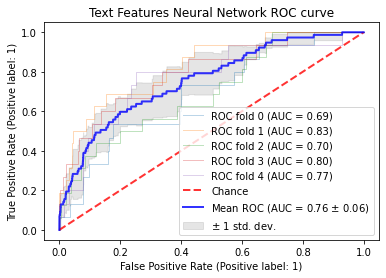

In [ ]:
from sklearn import svm, datasets
from sklearn.metrics import auc
from sklearn.metrics import plot_roc_curve

cv = StratifiedKFold(n_splits=5)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 10000)

fig, ax = plt.subplots()
for i, (train, test) in enumerate(cv.split(x4, y4)):
    neural_network1.fit(x4.iloc[train], y4.iloc[train])
    viz = plot_roc_curve(neural_network1, x4.iloc[test], y4.iloc[test],
                         name='ROC fold {}'.format(i),
                         alpha=0.3, lw=1, ax=ax)
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
        label='Chance', alpha=.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
        lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                label=r'$\pm$ 1 std. dev.')

ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       title="Text Features Neural Network ROC curve")
ax.legend(loc="lower right")